# 基于熵权法-灰色关联分析的公司综合评价

## 项目概述
本项目使用**熵权法（Entropy Weight Method）**确定各评价指标的客观权重，
再结合**灰色关联分析（Grey Relational Analysis, GRA）**对 a、b、c、d、e、f、g 七家公司进行综合评价与排序。

## 方法流程
1. **数据预处理**：根据指标类型（偏大型/偏小型/中间型）进行无量纲化处理
2. **熵权法求权重**：基于信息熵计算各指标的客观权重
3. **灰色关联分析**：计算各公司与参考序列的灰色关联度
4. **结果分析**：根据关联度排序，得出综合评价结论


In [1]:
# ============================================
# 导入所需库
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from matplotlib import font_manager

# 设置中文字体（Windows 优先使用 Microsoft YaHei，支持粗体）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

# 显示设置
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 20)

print("所有库导入成功！")

所有库导入成功！


## 1. 数据读取

从 Excel 文件中读取原始数据，包含：
- 19个评价指标（C1~C19）
- 3种指标类型：**偏大型**（效益型，越大越好）、**偏小型**（成本型，越小越好）、**中间型**（适中型，越接近某值越好）
- 7家待评价公司（a~g）


In [2]:
# ============================================
# 读取数据
# ============================================
df = pd.read_excel('company_data.xlsx')

# 查看原始数据
print("原始数据：")
print(df.to_string(index=False))

# 提取关键信息
indicators = df['指标'].tolist()        # 指标名称列表
indicator_types = df['指标类型'].tolist()  # 指标类型列表
companies = ['a', 'b', 'c', 'd', 'e', 'f', 'g']  # 公司列表

# 提取数值矩阵：每行是一家公司，每列是一个指标
data = df[companies].values.T  # shape: (7家公司, 19个指标)

print(f"\n数据规模: {data.shape[0]} 家公司, {data.shape[1]} 个指标")
print(f"公司列表: {companies}")
print(f"\n指标类型分布:")
for t in set(indicator_types):
    count = indicator_types.count(t)
    idx_list = [indicators[i] for i, typ in enumerate(indicator_types) if typ == t]
    print(f"  {t} ({count}个): {idx_list}")


原始数据：
        指标 指标类型     a    b    c     d    e    f    g
   C1_产品品牌  中间型  81.0 82.3 66.7  89.8 77.8 88.6 88.4
   C2_产品质量  偏大型  94.7 88.6 77.8 100.0 87.9 79.4 83.2
    C3_性价比  偏大型  87.0 76.6 73.0  84.4 85.3 75.6 70.7
   C4_产品款式  偏大型  89.1 71.7 74.4  81.2 75.1 62.3 68.8
   C5_产品包装  中间型  65.3 68.4 77.2  80.8 69.3 73.1 76.7
  C6_店铺信用度  偏大型 100.0 76.5 84.6  92.6 81.6 72.1 77.8
   C7_售后服务  偏大型  86.9 78.8 81.1  93.2 78.1 73.7 70.9
    C8_材料费  偏小型  21.8 21.8 27.3   8.6 38.4 37.9 38.1
   C9_运输费用  偏小型  13.2 15.1 18.3   6.2 24.5 27.8 27.7
C10_设备维修费用  偏小型   8.6  5.1 12.6   6.5 16.7 19.0 22.0
  C11_运行费用  偏小型   7.8 18.8 16.1  13.2 23.8 26.7 28.2
C12_设备折旧费用  偏小型  15.7  8.1 19.8   6.2 19.0 23.9 17.5
  C13_人员工资  偏小型  25.8 27.5 26.8  18.3 33.9 30.1 40.0
  C14_电耗费用  偏小型   6.5  4.8 11.6   4.0 15.1 17.7 13.8
  C15_水耗费用  偏小型   5.1  6.3  9.4   0.6 10.7  9.1  8.2
C16_销售人员能力  偏大型  78.0 68.6 83.2  88.3 65.2 76.6 73.9
  C17_广告宣传  偏大型  73.2 61.0 76.6  85.7 61.8 70.2 58.0
  C18_行业需求  偏大型  70.1 74.4 90.1  79.3 71

## 2. 数据归一化（无量纲化处理）

由于各指标的量纲和数量级不同，需要先进行归一化处理。归一化方法取决于指标类型：

- **偏大型（效益型）**：$x'_{ij} = \frac{x_{ij} - \min(x_j)}{\max(x_j) - \min(x_j)}$
- **偏小型（成本型）**：$x'_{ij} = \frac{\max(x_j) - x_{ij}}{\max(x_j) - \min(x_j)}$
- **中间型（适中型）**：$x'_{ij} = 1 - \frac{|x_{ij} - x_{best}|}{\max(|x_j - x_{best}|)}$

其中 $x_{best}$ 取该指标在所有公司中的**均值**作为最佳值。


In [3]:
# ============================================
# 数据归一化
# ============================================

def normalize_matrix(data, indicator_types):
    """
    根据指标类型对数据矩阵进行归一化处理

    参数:
        data: numpy array, shape (n_companies, n_indicators)
        indicator_types: list, 每个指标的类型标签

    返回:
        norm_data: 归一化后的矩阵 (0~1之间)
    """
    n_companies, n_indicators = data.shape
    norm_data = np.zeros_like(data, dtype=np.float64)

    for j in range(n_indicators):
        col = data[:, j].astype(np.float64)
        col_min = col.min()
        col_max = col.max()
        typ = indicator_types[j]

        if typ == '偏大型':  # 效益型：越大越好
            if col_max == col_min:
                norm_data[:, j] = 1.0  # 所有值相同则归一化为1
            else:
                norm_data[:, j] = (col - col_min) / (col_max - col_min)

        elif typ == '偏小型':  # 成本型：越小越好
            if col_max == col_min:
                norm_data[:, j] = 1.0
            else:
                norm_data[:, j] = (col_max - col) / (col_max - col_min)

        elif typ == '中间型':  # 适中型：越接近均值越好
            best_val = col.mean()  # 取均值作为最佳值
            max_deviation = np.abs(col - best_val).max()
            if max_deviation == 0:
                norm_data[:, j] = 1.0
            else:
                norm_data[:, j] = 1 - np.abs(col - best_val) / max_deviation
        else:
            raise ValueError(f"未知的指标类型: {typ}")

    return norm_data

# 执行归一化
norm_data = normalize_matrix(data, indicator_types)

# 将归一化结果转为 DataFrame 便于查看
norm_df = pd.DataFrame(norm_data.T, index=indicators, columns=companies).T
norm_df.index.name = '公司'

print("归一化后的数据（0~1，越接近1越优）：")
print(norm_df.round(4).to_string())


归一化后的数据（0~1，越接近1越优）：
    C1_产品品牌  C2_产品质量  C3_性价比  C4_产品款式  C5_产品包装  C6_店铺信用度  C7_售后服务  C8_材料费  C9_运输费用  C10_设备维修费用  C11_运行费用  C12_设备折旧费用  C13_人员工资  C14_电耗费用  C15_水耗费用  C16_销售人员能力  C17_广告宣传  C18_行业需求  C19_家庭需求
公司                                                                                                                                                                                          
a    0.9294   0.7613  1.0000   1.0000   0.0201    1.0000   0.7175  0.5570   0.6759      0.7929    1.0000      0.4633    0.6544    0.8175    0.5545      0.5541    0.5487    0.1803    0.4890
b    0.9861   0.4865  0.3620   0.3507   0.4161    0.1577   0.3543  0.5570   0.5880      1.0000    0.4608      0.8927    0.5760    0.9416    0.4356      0.1472    0.1083    0.3566    0.1630
c    0.0000   0.0000  0.1411   0.4515   0.4599    0.4480   0.4574  0.3725   0.4398      0.5562    0.5931      0.2316    0.6083    0.4453    0.1287      0.7792    0.6715    1.0000    1.0000
d    0.4986   1.0000  0.8405   0.7

## 3. 熵权法计算指标权重

熵权法的核心思想：**信息熵越小，说明该指标数据的差异越大，提供的信息越多，权重应越大。**

### 计算步骤：
1. 计算每个指标下各公司的**比重**：$p_{ij} = \frac{x'_{ij}}{\sum_{i=1}^{n} x'_{ij}}$
2. 为避免 $p_{ij}=0$ 导致 $\ln(0)$ 无意义，做微小平移修正
3. 计算**信息熵**：$e_j = -\frac{1}{\ln(n)} \sum_{i=1}^{n} p_{ij} \ln(p_{ij})$
4. 计算**权重**：$w_j = \frac{1 - e_j}{\sum_{j=1}^{m} (1 - e_j)}$


In [4]:
# ============================================
# 熵权法求权重
# ============================================

def entropy_weight_method(norm_data):
    """
    使用熵权法计算各指标的客观权重

    参数:
        norm_data: 归一化后的矩阵, shape (n_companies, n_indicators)

    返回:
        weights: 各指标权重, shape (n_indicators,)
    """
    n, m = norm_data.shape

    # Step 1: 计算比重 p_ij
    # 为避免除以0，对全零列做处理
    col_sums = norm_data.sum(axis=0)
    p = norm_data / col_sums

    # Step 2: 处理 p_ij = 0 的情况（微小平移，保证 ln 有意义）
    # 若 p_ij = 0，则 p_ij * ln(p_ij) = 0（取极限），因此直接设 epsilon
    epsilon = 1e-12
    p_safe = np.where(p < epsilon, epsilon, p)

    # Step 3: 计算信息熵 e_j
    k = 1.0 / np.log(n)  # 归一化常数
    e = -k * np.sum(p_safe * np.log(p_safe), axis=0)

    # Step 4: 计算差异系数 d_j = 1 - e_j
    d = 1 - e

    # Step 5: 计算权重 w_j
    weights = d / d.sum()

    return weights, e, d

# 执行熵权法
weights, entropy, diff_coeff = entropy_weight_method(norm_data)

# 整理权重结果为 DataFrame
weight_df = pd.DataFrame({
    '指标': indicators,
    '指标类型': indicator_types,
    '信息熵': entropy.round(4),
    '差异系数': diff_coeff.round(4),
    '权重': weights.round(4)
})
weight_df = weight_df.sort_values('权重', ascending=False)

print("熵权法求得的各指标权重（按权重降序排列）：")
print(weight_df.to_string(index=False))
print(f"\n权重之和: {weights.sum():.6f}")


熵权法求得的各指标权重（按权重降序排列）：
        指标 指标类型    信息熵   差异系数     权重
    C8_材料费  偏小型 0.7056 0.2944 0.0905
   C9_运输费用  偏小型 0.7648 0.2352 0.0723
  C15_水耗费用  偏小型 0.7997 0.2003 0.0616
  C17_广告宣传  偏大型 0.8084 0.1916 0.0589
  C11_运行费用  偏小型 0.8142 0.1858 0.0571
   C2_产品质量  偏大型 0.8145 0.1855 0.0570
   C5_产品包装  中间型 0.8144 0.1856 0.0570
  C6_店铺信用度  偏大型 0.8240 0.1760 0.0541
    C3_性价比  偏大型 0.8311 0.1689 0.0519
   C7_售后服务  偏大型 0.8350 0.1650 0.0507
  C19_家庭需求  偏大型 0.8396 0.1604 0.0493
  C18_行业需求  偏大型 0.8413 0.1587 0.0488
C12_设备折旧费用  偏小型 0.8440 0.1560 0.0479
  C14_电耗费用  偏小型 0.8447 0.1553 0.0478
C10_设备维修费用  偏小型 0.8526 0.1474 0.0453
C16_销售人员能力  偏大型 0.8545 0.1455 0.0447
   C4_产品款式  偏大型 0.8679 0.1321 0.0406
  C13_人员工资  偏小型 0.8865 0.1135 0.0349
   C1_产品品牌  中间型 0.9043 0.0957 0.0294

权重之和: 1.000000


### 3.1 权重可视化

通过柱状图直观展示各指标的权重分布。


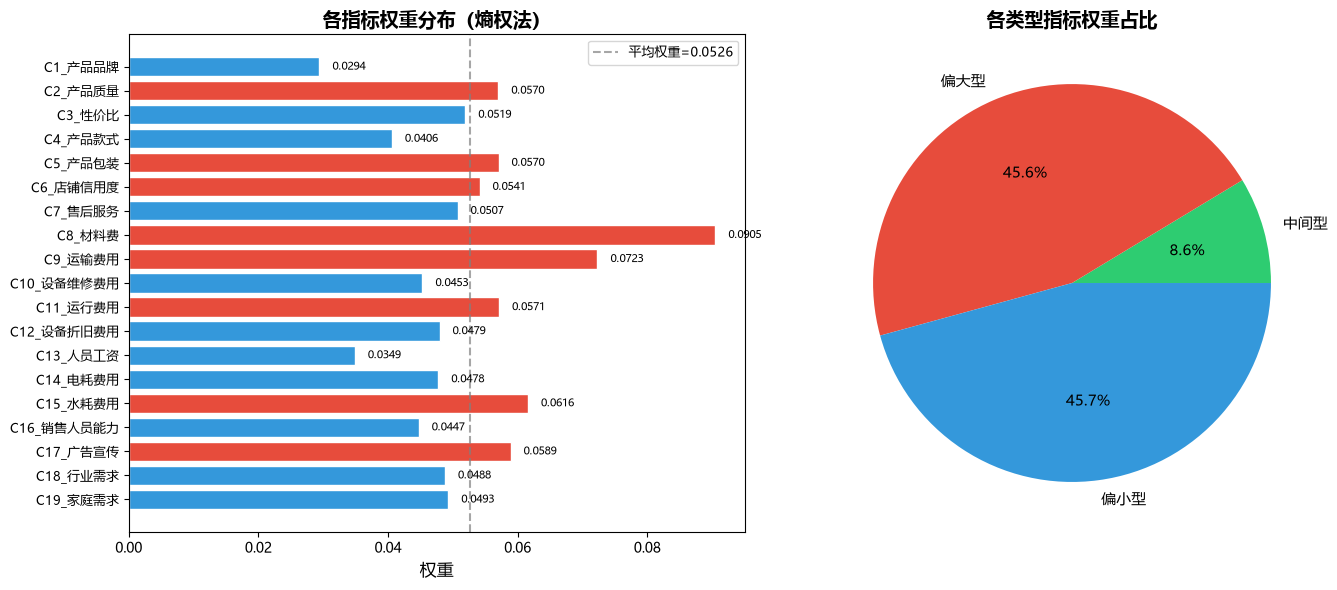

权重分布图已保存为 weight_distribution.png


In [5]:
# ============================================
# 权重可视化
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 左图：权重柱状图
ax1 = axes[0]
colors = ['#e74c3c' if w > weights.mean() else '#3498db' for w in weights]
bars = ax1.barh(range(len(indicators)), weights, color=colors, edgecolor='white')
ax1.set_yticks(range(len(indicators)))
ax1.set_yticklabels(indicators, fontsize=9)
ax1.set_xlabel('权重', fontsize=12)
ax1.set_title('各指标权重分布（熵权法）', fontsize=14, fontweight='bold')
ax1.invert_yaxis()
ax1.axvline(x=1/len(indicators), color='gray', linestyle='--', alpha=0.7, label=f'平均权重={1/len(indicators):.4f}')
ax1.legend(fontsize=9)

# 标注权重值
for i, (bar, w) in enumerate(zip(bars, weights)):
    ax1.text(w + 0.002, bar.get_y() + bar.get_height()/2, f'{w:.4f}', va='center', fontsize=8)

# 右图：信息熵饼图（按指标分类）
ax2 = axes[1]
type_weight = {}
for typ, w in zip(indicator_types, weights):
    type_weight[typ] = type_weight.get(typ, 0) + w

type_labels = list(type_weight.keys())
type_vals = list(type_weight.values())
colors_pie = ['#2ecc71', '#e74c3c', '#3498db']
wedges, texts, autotexts = ax2.pie(
    type_vals, labels=type_labels, autopct='%1.1f%%',
    colors=colors_pie[:len(type_labels)],
    textprops={'fontsize': 11}
)
ax2.set_title('各类型指标权重占比', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('weight_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("权重分布图已保存为 weight_distribution.png")


## 4. 灰色关联分析 (GRA)

灰色关联分析的基本思想：**通过比较各评价对象与"理想对象"的相似程度来判断优劣。**

### 计算步骤：
1. 用归一化数据乘以权重，得到**加权归一化矩阵**
2. 确定**参考序列**（理想解）：每个指标取最大值
3. 计算**绝对差矩阵**：$\Delta_{ij} = |r_{0j} - r_{ij}|$
4. 计算**灰色关联系数**：$\xi_{ij} = \frac{\min\Delta + \rho \cdot \max\Delta}{\Delta_{ij} + \rho \cdot \max\Delta}$
   - $\rho$ 为分辨系数，通常取 0.5
5. 计算**灰色关联度**（加权求和）：$\gamma_i = \sum_{j=1}^{m} w_j \cdot \xi_{ij}$


In [6]:
# ============================================
# 灰色关联分析
# ============================================

def grey_relational_analysis(norm_data, weights, rho=0.5):
    """
    进行灰色关联分析

    参数:
        norm_data: 归一化后的矩阵, shape (n_companies, n_indicators)
        weights: 各指标权重, shape (n_indicators,)
        rho: 分辨系数，默认0.5

    返回:
        rel_grade: 各公司的灰色关联度, shape (n_companies,)
        rel_coeff: 灰色关联系数矩阵, shape (n_companies, n_indicators)
    """
    n, m = norm_data.shape

    # Step 1: 加权归一化矩阵
    weighted_data = norm_data * weights

    # Step 2: 确定参考序列（每列取最大值作为理想值）
    ref_sequence = np.max(weighted_data, axis=0)

    # Step 3: 计算绝对差矩阵
    delta = np.abs(ref_sequence - weighted_data)

    # Step 4: 计算灰色关联系数
    delta_min = delta.min()
    delta_max = delta.max()

    rel_coeff = (delta_min + rho * delta_max) / (delta + rho * delta_max)

    # Step 5: 计算灰色关联度（按权重加权）
    # 由于前面已经乘过权重，这里直接用均值即可
    # 也可以重新加权：rel_grade = np.sum(rel_coeff * weights, axis=1)
    rel_grade = np.sum(rel_coeff * weights, axis=1)

    return rel_grade, rel_coeff, weighted_data, ref_sequence, delta

# 执行灰色关联分析
rel_grade, rel_coeff, weighted_data, ref_sequence, delta = grey_relational_analysis(
    norm_data, weights, rho=0.5
)

# 整理结果
result_df = pd.DataFrame({
    '公司': companies,
    '灰色关联度': rel_grade.round(6)
})
result_df = result_df.sort_values('灰色关联度', ascending=False)
result_df['排名'] = range(1, len(companies) + 1)
result_df = result_df.reset_index(drop=True)

print("=" * 50)
print("灰色关联分析最终评价结果")
print("=" * 50)
print(result_df.to_string(index=False))

# 关联系数矩阵
coeff_df = pd.DataFrame(
    rel_coeff.T, index=indicators, columns=companies
).T
coeff_df.index.name = '公司'
print(f"\n灰色关联系数矩阵：")
print(coeff_df.round(4).to_string())


灰色关联分析最终评价结果
公司    灰色关联度  排名
 d 0.891155   1
 a 0.735631   2
 b 0.635479   3
 c 0.629996   4
 f 0.547955   5
 e 0.547008   6
 g 0.504406   7

灰色关联系数矩阵：
    C1_产品品牌  C2_产品质量  C3_性价比  C4_产品款式  C5_产品包装  C6_店铺信用度  C7_售后服务  C8_材料费  C9_运输费用  C10_设备维修费用  C11_运行费用  C12_设备折旧费用  C13_人员工资  C14_电耗费用  C15_水耗费用  C16_销售人员能力  C17_广告宣传  C18_行业需求  C19_家庭需求
公司                                                                                                                                                                                          
a    0.9645   0.7688  1.0000   1.0000   0.4515    1.0000   0.7595  0.5302   0.6588      0.8282    1.0000      0.6375    0.7896    0.8385    0.6225      0.6941    0.6299    0.5309    0.6424
b    1.0000   0.6072  0.5773   0.6319   0.5829    0.4982   0.5801  0.5302   0.6030      1.0000    0.5950      0.8979    0.7537    0.9420    0.5656      0.5426    0.4628    0.5904    0.5231
c    0.6093   0.4425  0.5036   0.6702   0.6023    0.6023   0.6218  0.4435   0.5276      0.69

## 5. 结果可视化

对最终评价结果进行可视化展示。


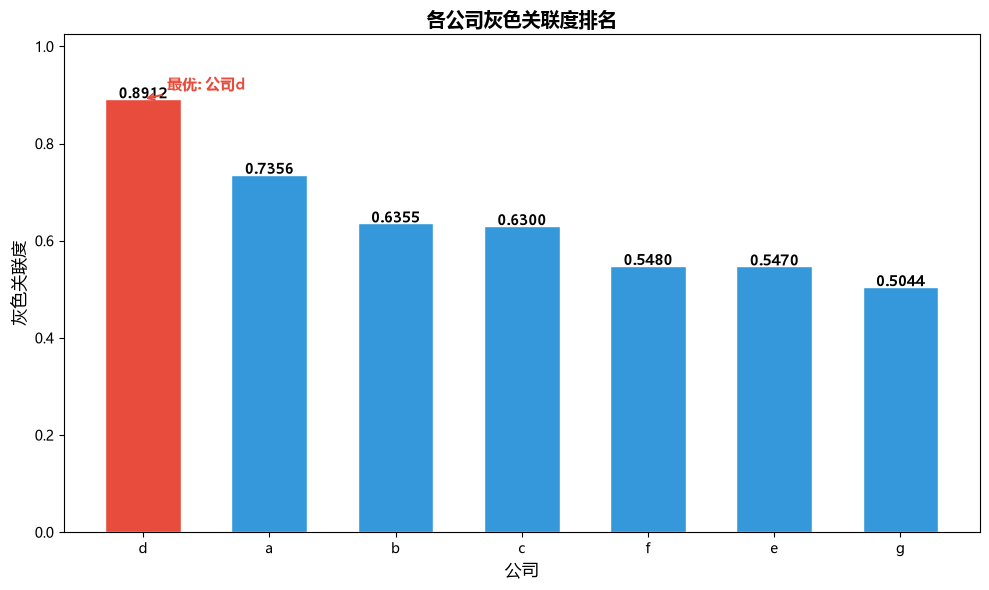

评估结果柱状图已保存为 evaluation_results_bar.png


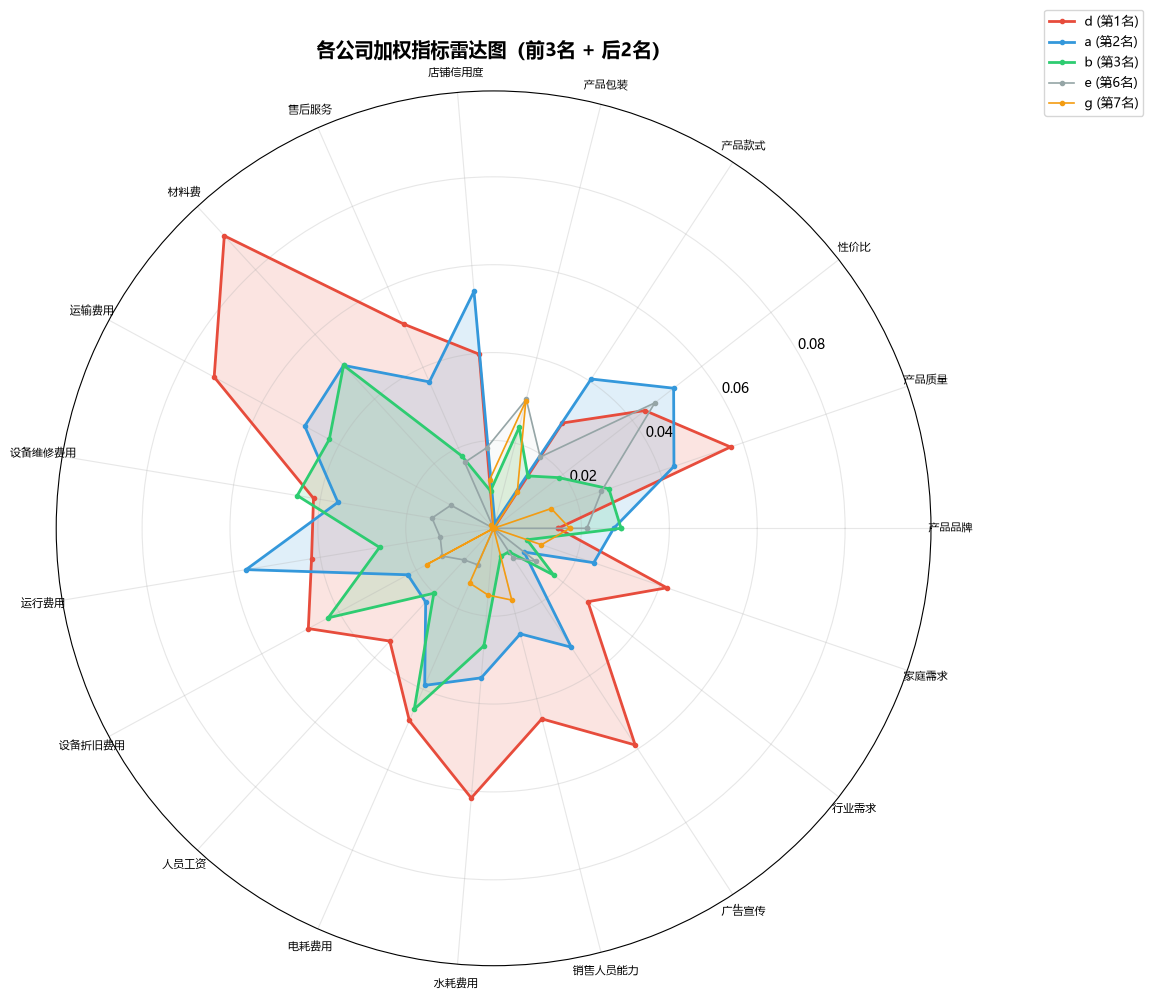

雷达图已保存为 evaluation_results_radar.png
所有评价结果图保存完毕。


In [7]:
# ============================================
# 结果可视化
# ============================================

# 排序后的结果
sorted_companies = result_df['公司'].tolist()
sorted_grades = result_df['灰色关联度'].tolist()

# ==================== 左图：灰色关联度柱状图 ====================
fig1, ax1 = plt.subplots(figsize=(10, 6))

grade_colors = []
top1 = result_df['公司'].iloc[0]
for c in sorted_companies:
    if c == top1:
        grade_colors.append('#e74c3c')  # 最优为红色
    else:
        grade_colors.append('#3498db')

bars = ax1.bar(sorted_companies, sorted_grades, color=grade_colors, edgecolor='white', width=0.6)
ax1.set_xlabel('公司', fontsize=12)
ax1.set_ylabel('灰色关联度', fontsize=12)
ax1.set_title('各公司灰色关联度排名', fontsize=14, fontweight='bold')
ax1.set_ylim(0, max(sorted_grades) * 1.15)

# 标注数值
for bar, grade in zip(bars, sorted_grades):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
             f'{grade:.4f}', ha='center', fontsize=10, fontweight='bold')

# 标注最优
ax1.annotate(f'最优: 公司{top1}', xy=(0, sorted_grades[0]),
             xytext=(0.5, sorted_grades[0] + 0.02),
             fontsize=11, fontweight='bold', color='#e74c3c',
             ha='center',
             arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=1.5))

plt.tight_layout()
plt.savefig('evaluation_results_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("评估结果柱状图已保存为 evaluation_results_bar.png")

# ==================== 右图：雷达图（极坐标） ====================
# 提取简化指标名称（去掉"C#_"前缀，保留核心名称）
short_labels = []
for ind in indicators:
    # 提取下划线后的部分，如果没有下划线则保留原样
    parts = ind.split('_', 1)
    short_labels.append(parts[1] if len(parts) > 1 else ind)

n_indicators = len(indicators)
angles = np.linspace(0, 2 * np.pi, n_indicators, endpoint=False).tolist()
angles += angles[:1]  # 闭合

# 选择前3名和后2名画雷达图
top3 = result_df['公司'].head(3).tolist()
bottom2 = result_df['公司'].tail(2).tolist()
plot_companies = top3 + bottom2

# 定义颜色
radar_colors = ['#e74c3c', '#3498db', '#2ecc71', '#95a5a6', '#f39c12']

# 创建极坐标雷达图
fig2, ax2 = plt.subplots(figsize=(12, 10), subplot_kw={'projection': 'polar'})

for i, company in enumerate(plot_companies):
    idx = companies.index(company)
    values = weighted_data[idx].tolist()
    values += values[:1]  # 闭合

    rank = result_df[result_df['公司'] == company]['排名'].values[0]

    if i < 3:
        alpha_fill = 0.15
        lw = 2.0
        label = f'{company} (第{rank}名)'
    else:
        alpha_fill = 0.05
        lw = 1.2
        label = f'{company} (第{rank}名)'

    ax2.fill(angles, values, alpha=alpha_fill, color=radar_colors[i])
    ax2.plot(angles, values, 'o-', linewidth=lw, color=radar_colors[i], label=label, markersize=3)

# 设置雷达图属性
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(short_labels, fontsize=8)
ax2.set_ylim(0, max(weighted_data.max(axis=1)) * 1.1)
ax2.set_title('各公司加权指标雷达图（前3名 + 后2名）', fontsize=14, fontweight='bold', pad=25)
ax2.legend(loc='upper right', bbox_to_anchor=(1.25, 1.1), fontsize=9)
ax2.set_rlabel_position(30)  # 调整径向标签位置
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('evaluation_results_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print("雷达图已保存为 evaluation_results_radar.png")

print("所有评价结果图保存完毕。")

## 6. 各指标关联系数热力图

通过热力图直观展示各公司在每个指标上的灰色关联系数，帮助识别各公司的优势和劣势。


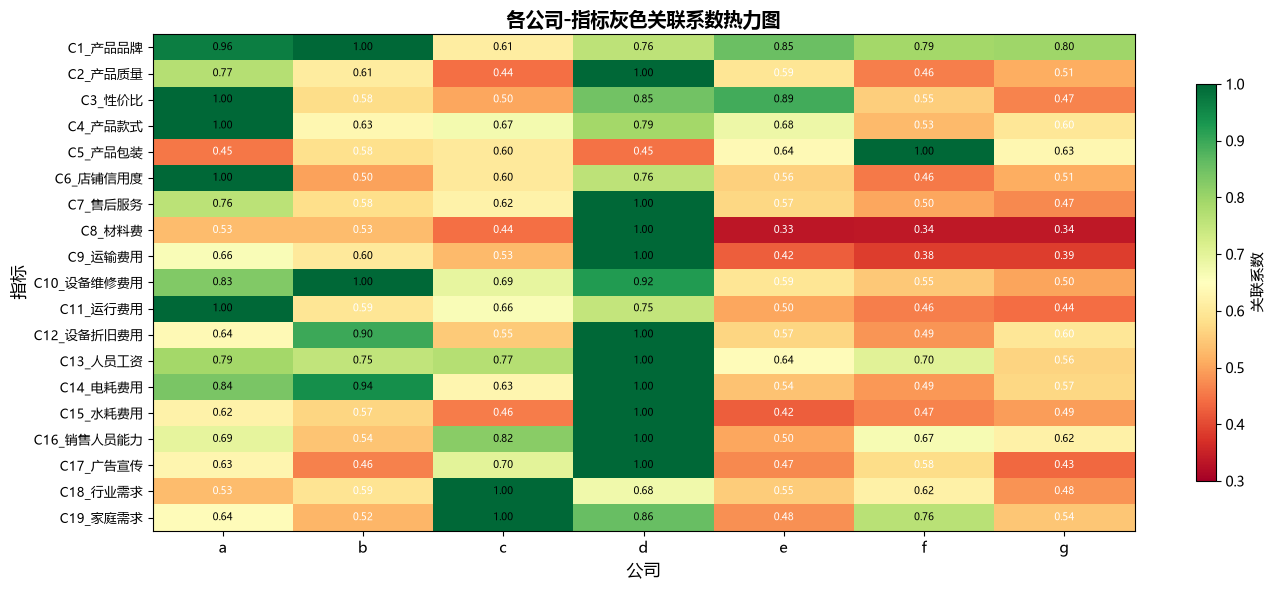

热力图已保存为 correlation_heatmap.png


In [8]:
# ============================================
# 关联系数热力图
# ============================================

fig, ax = plt.subplots(figsize=(14, 6))

im = ax.imshow(rel_coeff.T, cmap='RdYlGn', aspect='auto', vmin=0.3, vmax=1.0)

# 坐标轴设置
ax.set_xticks(range(len(companies)))
ax.set_yticks(range(len(indicators)))
ax.set_xticklabels(companies, fontsize=11)
ax.set_yticklabels(indicators, fontsize=9)

# 在每个单元格标注数值
for i in range(len(indicators)):
    for j in range(len(companies)):
        val = rel_coeff[j, i]
        text_color = 'white' if val < 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7, color=text_color)

ax.set_xlabel('公司', fontsize=12)
ax.set_ylabel('指标', fontsize=12)
ax.set_title('各公司-指标灰色关联系数热力图', fontsize=14, fontweight='bold')

# 颜色条
cbar = plt.colorbar(im, ax=ax, shrink=0.8)
cbar.set_label('关联系数', fontsize=11)

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("热力图已保存为 correlation_heatmap.png")


## 7. 结论与分析

### 评价方法总结
本分析采用 **熵权法 + 灰色关联分析** 的组合评价模型：
- **熵权法**客观地从数据本身的信息量出发确定权重，避免了主观赋权的随意性
- **灰色关联分析**通过衡量各公司与理想解的"距离"，给出综合评分

### 指标合理性说明
- 对于具有**固定最佳值**的中间型指标（如产品品质、产品包装），若存在公认的标准值，可替换均值作为最佳值以提高合理性
- 若有专家经验，可在熵权法基础上结合**层次分析法（AHP）**进行组合赋权


In [9]:
# ============================================
# 输出最终评价结果表
# ============================================

# 最终汇总表
print("╔" + "═" * 60 + "╗")
print("║" + "  基于熵权法-灰色关联分析的公司综合评价结果".center(56) + "║")
print("╠" + "═" * 60 + "╣")
print(f"║  {'排名':<4} {'公司':<6} {'灰色关联度':<12} {'评价等级':<10}       ║")
print("╠" + "═" * 60 + "╣")

max_grade = result_df['灰色关联度'].max()
min_grade = result_df['灰色关联度'].min()

for _, row in result_df.iterrows():
    rank = int(row['排名'])
    company = row['公司']
    grade = row['灰色关联度']

    # 评价等级
    if grade >= max_grade * 0.9:
        level = '优秀'
    elif grade >= max_grade * 0.8:
        level = '良好'
    elif grade >= max_grade * 0.7:
        level = '中等'
    else:
        level = '一般'

    print(f"║  {rank:<4} {company:<6} {grade:<12.6f} {level:<10}       ║")

print("╚" + "═" * 60 + "╝")

print(f"\n最佳公司: 公司{result_df['公司'].iloc[0]} (关联度={result_df['灰色关联度'].iloc[0]:.6f})")
print(f"最差公司: 公司{result_df['公司'].iloc[-1]} (关联度={result_df['灰色关联度'].iloc[-1]:.6f})")
print(f"极差: {max_grade - min_grade:.6f}")


╔════════════════════════════════════════════════════════════╗
║                  基于熵权法-灰色关联分析的公司综合评价结果                 ║
╠════════════════════════════════════════════════════════════╣
║  排名   公司     灰色关联度        评价等级             ║
╠════════════════════════════════════════════════════════════╣
║  1    d      0.891155     优秀               ║
║  2    a      0.735631     良好               ║
║  3    b      0.635479     中等               ║
║  4    c      0.629996     中等               ║
║  5    f      0.547955     一般               ║
║  6    e      0.547008     一般               ║
║  7    g      0.504406     一般               ║
╚════════════════════════════════════════════════════════════╝

最佳公司: 公司d (关联度=0.891155)
最差公司: 公司g (关联度=0.504406)
极差: 0.386749
